# Task 1.1 — BERT for Sentiment Analysis

This notebook trains a Transformer-based sentiment classifier with BERT and evaluates it on the same test split used for the other models.

In [1]:
!pip install transformers

In [2]:
import random
from typing import Dict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from utils import device_check, stratified_split
from utils_BERT import (
    build_bert_loaders,
    fit_bert,
    evaluate_bert,
    plot_confusion_matrix_bert,
)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [3]:
LOG_WANDB   = True  # Set False to disable wandb logging
NUM_WORKERS = 8
# PIN_MEMORY  = True # This is defined inside build_bert_loaders function for now! didn't have time to fix itand make it like Task 1.1!
SEED = 1
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 50

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = device_check()

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


## Load the Pre-Split CSV Files

In this notebook, we use the preprocessed CSV files generated earlier.
This keeps the data split consistent across all models and ensures a fair comparison in Task 1.3.

In [4]:
from pathlib import Path
import pandas as pd

SPLITS_DIR = Path("../data/splits")

train_df = pd.read_csv(SPLITS_DIR / "25k_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "25k_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "25k_test.csv")

NUM_LABELS = 2 # Check this before moving forward. Should be 5 if using Video Game dataset
NUM_CLASSES = 2 # Change this according to NUM_LABELS

# the following three lines should be run if you want to use Video Game data 
# train_df[label_col] = train_df[label_col].astype(int) - 1
# val_df[label_col] = val_df[label_col].astype(int) - 1
# test_df[label_col] = test_df[label_col].astype(int) - 1


## Tokenizer and DataLoaders

BERT needs `input_ids` and `attention_mask`, so we tokenize the text before training.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

text_col = "Sentence"
label_col = "Class"


loaders = build_bert_loaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    text_col=text_col,
    label_col=label_col,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

## Model

We use `AutoModelForSequenceClassification` with five labels for binary sentiment classification.

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6498.75it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

## Training

The model is trained on the training split and validated after every epoch.
The best checkpoint is restored automatically.

In [7]:
history = fit_bert(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs={
        "project": "lab1-bert-sentiment",
        "name": "bert-base-uncased",
    },
    scheduler=None,
    log=LOG_WANDB,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch  1/50 | train loss 0.3535, train acc 84.49% | val loss 0.2764, val acc 89.07%
Epoch  2/50 | train loss 0.2223, train acc 91.52% | val loss 0.3140, val acc 88.36%
Epoch  3/50 | train loss 0.1253, train acc 95.62% | val loss 0.3515, val acc 88.58%
Epoch  4/50 | train loss 0.0698, train acc 97.79% | val loss 0.4242, val acc 88.76%
Epoch  5/50 | train loss 0.0457, train acc 98.63% | val loss 0.4528, val acc 87.82%
Epoch  6/50 | train loss 0.0349, train acc 98.97% | val loss 0.4825, val acc 88.36%
Epoch  7/50 | train loss 0.0283, train acc 99.20% | val loss 0.4861, val acc 88.53%
Epoch  8/50 | train loss 0.0230, train acc 99.34% | val loss 0.6257, val acc 88.44%
Epoch  9/50 | train loss 0.0209, train acc 99.35% | val loss 0.6772, val acc 87.87%
Epoch 10/50 | train loss 0.0183, train acc 99.44% | val loss 0.5306, val acc 87.64%
Epoch 11/50 | train loss 0.0143, train acc 99.53% | val loss 0.5861, val acc 87.73%
Epoch 12/50 | train loss 0.0116, train acc 99.61% | val loss 0.6813, val acc

Training Accuracy,▁▄▆▇▇███████████████████████████████████
Training Loss,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
Validation Accuracy,█▆▇▇▅▇▆▅▄▅▃▅▄▁▃▆▅▇▆▆▅▆▅▆▆▆▆▆▆▃▄▅▄▄▆▄▄▆▄▄
Validation Loss,▁▁▂▃▃▅▆▄▅▆▆▆▇▅▇▆▅▆█▆▆▇█▆▇▆▅▇▆▇█▄▆▆▆▆▇█▇▇
Training Accuracy,99.92099
Training Loss,0.00502
Validation Accuracy,87.37778
Validation Loss,0.83542



Restored best weights (val loss 0.2764)


## Final Test Evaluation

The final result is reported on the held-out test set for fair comparison with the ANN and LSTM models.

In [8]:
test_loss, test_acc = evaluate_bert(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    label="BERT",
)

[BERT] Test loss: 0.2911 | Test acc: 88.08%


## Confusion Matrix

This helps visualize which classes are being predicted correctly and which ones are confused.

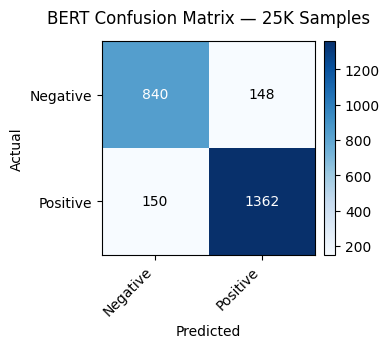

In [9]:
plot_confusion_matrix_bert(
    model=model,
    loader=test_loader,
    num_classes=NUM_CLASSES,
    device=device,
    class_names=["Negative", "Positive"],
    title='BERT Confusion Matrix — 25K Samples',
)